In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
P = np.array([
    [0.224, 0.248, 0.390, 0.138],
    [0.251, 0.360, 0.101, 0.288],
    [0.197, 0.300, 0.341, 0.162],
    [0.136, 0.277, 0.396, 0.190]
])
P = P / P.sum(axis=1)[:, np.newaxis]
nucs = ['A', 'C', 'G', 'T']
nuc_to_idx = {n: i for i, n in enumerate(nucs)}


def generate_sequence(P, length, start_state):
    seq_indices = [nuc_to_idx[start_state]]
    for _ in range(length - 1):
        current_state = seq_indices[-1]
        next_state = np.random.choice(4, p=P[current_state])
        seq_indices.append(next_state)
    return "".join([nucs[i] for i in seq_indices])

In [6]:
num_seqs = 10
seq_len = 1000
sequences = [generate_sequence(P, seq_len, 'A') for _ in range(num_seqs)]

def get_empirical_matrix(sequences):
    emp_matrix = np.zeros((4, 4))
    for seq in sequences:
        for i in range(len(seq) - 1):
            idx_from = nuc_to_idx[seq[i]]
            idx_to = nuc_to_idx[seq[i+1]]
            emp_matrix[idx_from, idx_to] += 1
    row_sums = emp_matrix.sum(axis=1)
    return emp_matrix / row_sums[:, np.newaxis]

empirical_P = get_empirical_matrix(sequences)

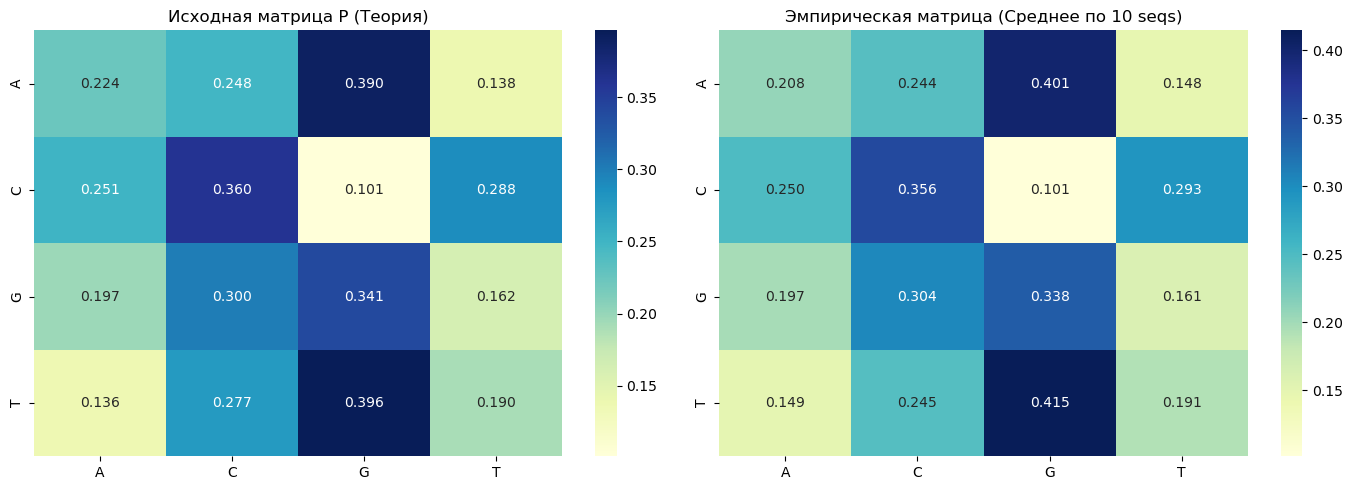

Среднее отклонение (MAE): 0.0078
Максимальное отклонение: 0.0324


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(P, annot=True, fmt=".3f", xticklabels=nucs, yticklabels=nucs, cmap="YlGnBu", ax=ax[0])
ax[0].set_title("Исходная матрица P (Теория)")

sns.heatmap(empirical_P, annot=True, fmt=".3f", xticklabels=nucs, yticklabels=nucs, cmap="YlGnBu", ax=ax[1])
ax[1].set_title(f"Эмпирическая матрица (Среднее по {num_seqs} seqs)")

plt.tight_layout()
plt.show()

diff = np.abs(P - empirical_P)
print(f"Среднее отклонение (MAE): {np.mean(diff):.4f}")
print(f"Максимальное отклонение: {np.max(diff):.4f}")